# ```Seminar 2: Epipolar geometry and Fundamental matrix```

### Plan

- Implement the eight-point algorithm
- Compute the fundamental matrix $\mathrm F$ for a pair of real images using all correspondences
- Visualize epipolar lines using the fundamental matrix
- For points on the left image find the corresponding points from the right one using SIFT algorithm

## Theory

### Epipolar geometry

<div style="max-width:500px;margin-right: auto; margin-right: 0;">
    
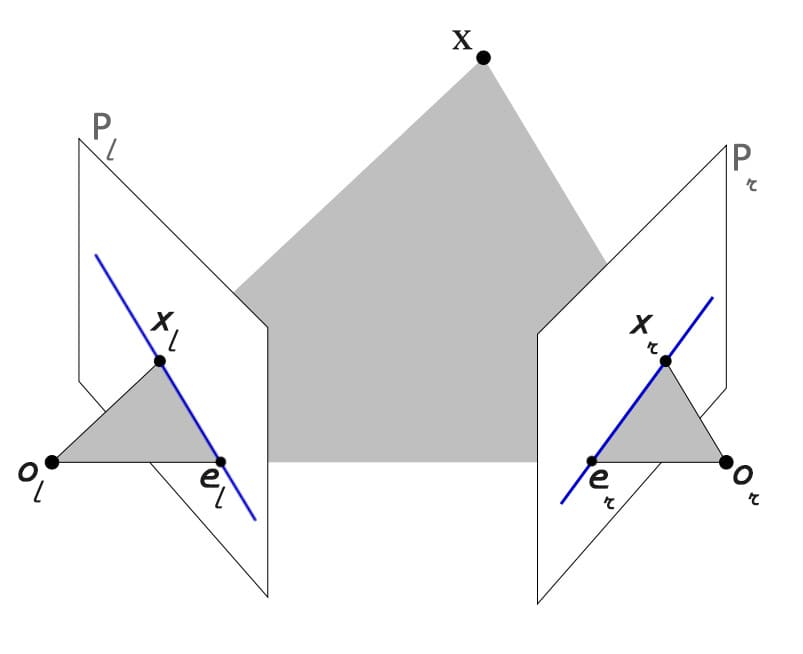
</div>

Here:
- $x$ - object position.
- $o_l, o_r$ - centers of two cameras.
- White planes $P_l, P_r$ - image planes. This is where object $x$ is projected on.
- $x_l, x_r$ - projections of $x$ onto image planes $P_l$ and $P_r$. These are observations of point $x$ by cameras.
- Epipole $e_l$ is the projection of the right camera's center $o_r$ onto the left image plane $P_l$. Also, epipole $e_r$ - the projection of $o_l$ onto $P_r$. So, epipoles are projections of one camera onto image plane of another camera.
- Epipolar lines - blue lines $x_l e_l$ and $x_r e_r$.

**What are epipolar lines?**

Suppose we only know camera centers ($o_l$, $o_r$), epipolar planes ($P_l$, $P_r$) and projection of object onto the left image plane $x_l$, but have no information about where object $x$ is. We still can get epipoles $e_l, e_r$ - these are intersections of line $o_l o_r$ with epipolar planes $P_l, P_r$.

But how to find $x_r$? Let's have a look at line $o_l x_l$: as $x_l$ is projection of $x$ onto $P_l$, then $x_l$ is on line between object and left camera ($x_l \in x o_l$), so object $x$ is somewhere on line $x_l o_l$. When we project this line onto right image plane $P_r$, $x_r$ will be somewhere on this projection. Note that right epipolar line goes through epipole $e_r$ (as it is projection of left camera center $o_l$) and $x_r$ (projection of the object onto this plane). All in all, epipolar line is where the projection of object can lie.

### Fundamental matrix

We have just described how to get the right epipolar line $I_r = e_r x_r$ by $x_l$ - point of object observation by left camera. In fact, it is exactly what fundamental matrix $F$ does: maps point $x_l$ from the left image plane $P_l$ to line on the other image plane $P_r$.

In case of 2d images: $F \in \mathbb{R}^{3 \times 3}$.

<div style="max-width:400px;margin-right: auto; margin-right: 0;">
    
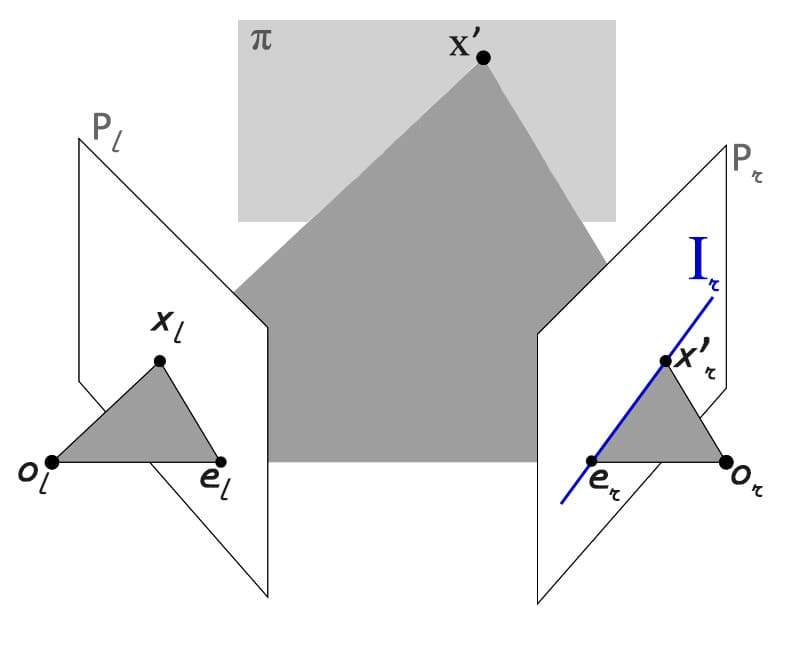

</div>

Suppose we know only coordinates of two cameras $o_l$ and $o_r$. How to get fundamental matrix F?

0. 1. - Let $\pi$ be a new plane, which defines the possible plane of the object.
      - Any point $x \in \mathbb{R}^4$ (in homogeneous coordinates) from $\pi$ is projected onto left image plane by homography $H_l \in \mathbb{R}^{3\times 4} \ (\text{rk } H_l=3)$: $x_l = H_l x$.
      - To get point $x$ on $\pi$ by $x_l$ from $P_l$, we need pseudo-inverse matrix $H_l^{\dagger} \in \mathbb{R}^{4\times 3}: H_l H_l^{\dagger} = I$
    2. $[e_r]_{\times}$ defines vector product over point $e_r$


1. - Choose a point $x_l \in P_l$.
   - First, we project $x_l$ onto $\pi$ to get point $x':= H_l^{\dagger} x_l$.
   - Then project $x'$ onto right image plane $P_r$ and get point $x'_r:= H_r x' = H_r H_l^{\dagger} x_l$.
     
This reprojection through $\pi$ maps point $x_l \in P_l$ to $x'_r \in P_r$ and is defined by homography matrix $H_{\pi} = H_r H_l^{\dagger}$.

2. - Project left camera $o_l$ onto $P_r$ to get epipole $e_r$
   - Now, we want to present line $I_r$ through points $x'_r$ and $e_r$, which is $[e_r]_{\times}x'_r$

Thus, line $I_r$ is constructed as $I_r = [e_r]_{\times}x'_r = [e_r]_{\times} H_r H_l^{\dagger} x_l = F x_l$.

**Fundamental matrix** $F = [e_r]_{\times} H_r H_l^{\dagger} = [e_r]_{\times} H_{\pi}$

#### Eight-point algorithm

Since fundamental matrix maps a point from left image plane to the corresponding epipolar line on the right one, $x_r^T F x_l=0$ for any corresponding pair $x_l \leftrightarrow x_r$. This is a linear equation in $F$, and we can solve it, having several corresponding pairs. From $F \in \mathbb{R}^{3 \times 3}$ there are 9 unknown variables, but fundamental matrix is defined up to a scale factor, so 8 linear equatations are essential. Therefore, at least 8 corresponding pairs are needed to find fundamental matrix $F$.

$x_l = \begin{pmatrix} x_1 \\ x_2 \\ x_3 \end{pmatrix} , \quad x_r = \begin{pmatrix} x'_1 \\ x'_2 \\ x'_3 \end{pmatrix},
\quad F = \begin{pmatrix} f_{11} & f_{12} & f_{13}  \\ f_{21} & f_{22} & f_{23}  \\ f_{31} & f_{32} & f_{33}  \end{pmatrix}$

$0 = x_r^TFx_l= \begin{pmatrix} x'_1 & x'_2 & x'_3 \end{pmatrix} \cdot \begin{pmatrix} f_{11} & f_{12} & f_{13}  \\ f_{21} & f_{22} & f_{23}  \\ f_{31} & f_{32} & f_{33} \end{pmatrix} \cdot \begin{pmatrix} x_1 \\ x_2 \\ x_3 \end{pmatrix} = \begin{pmatrix} x'_1 & x'_2 & x'_3 \end{pmatrix} \cdot \begin{pmatrix} f_{11}x_1 + f_{12}x_2 + f_{13}x_3  \\ f_{21}x_1 + f_{22}x_2 + f_{23}x_3  \\ f_{31}x_1 + f_{32}x_2 + f_{33}x_3  \end{pmatrix} = $

$ = f_{11}x'_1 x_1 + f_{12}x'_1 x_2 + f_{13}x'_1 x_3  + f_{21}x'_2 x_1 + f_{22}x'_2 x_2 + f_{23}x'_2 x_3 + f_{31}x'_3 x_1 + f_{32}x'_3 x_2 + f_{33}x'_3 x_3 =  \tilde{x}^T f$

где $f= \begin{pmatrix} f_{11} \\ f_{12} \\ f_{13} \\ f_{21} \\ f_{22} \\ f_{23} \\ f_{31} \\ f_{32} \\ f_{33} \\ \end{pmatrix}, \quad
\tilde{x} = \begin{pmatrix} x'_1 x_1 \\ x'_1 x_2 \\ x'_1 x_3 \\ x'_2 x_1 \\ x'_2 x_2 \\ x'_2 x_3 \\ x'_3 x_1 \\ x'_3 x_2 \\ x'_3 x_3 \end{pmatrix} $

Having 8 corresponding pairs and 8 equations $\tilde{x}_j^T f = 0$, we next construct matrix $\tilde{X} = \begin{pmatrix} \tilde{x}_1^T \\ \tilde{x}_2^T \\ ... \\ \tilde{x}_8^T \end{pmatrix} \in \mathbb{R}^{8\times 9}$ and solve $\tilde{X} f  = 0$.

$0 = \tilde{X} f = U \Sigma V^T f = U \Sigma \begin{pmatrix} v_1^T \\ ... \\ v_8^T \\ v_9^T \end{pmatrix} f$.

Choosing $f := v_9$, we solve the equation:
$U \Sigma \begin{pmatrix} v_1^T \\ ... \\ v_9^T \end{pmatrix} v_9 = U \Sigma \begin{pmatrix} 0 \\ ... \\ 0 \\ 1 \end{pmatrix} = U \begin{pmatrix} \sigma_1  & & & 0 \\ & \ddots & & 0 \\ & & \sigma_8 & 0 \end{pmatrix} \begin{pmatrix} 0 \\ ... \\ 0 \\ 1 \end{pmatrix} = 0$

# Code

In [2]:
import torch
import numpy as np
import matplotlib.pylab as plt
from tqdm import tqdm


def dehomogenize_points(points):
    return points[..., :-1] / (points[..., -1:] + 1e-8 * torch.sign(points[..., -1:]))


def homogenize_points(points):
    last_coordinate = torch.ones_like(points[..., -1:])
    return torch.cat((points, last_coordinate), dim=-1)

### Einsum examples

In [63]:
A = torch.randn(2, 3)

print(f"Matrix A:\n{A}")
# Transpose: swap i and j axes
AT = torch.einsum("ij->ji", A)
print(f"\nMatrix A^T:\n{AT}")

Matrix A:
tensor([[ 2.4997,  2.2446,  0.5160],
        [ 1.1694,  0.1094, -1.3515]])

Matrix A^T:
tensor([[ 2.4997,  1.1694],
        [ 2.2446,  0.1094],
        [ 0.5160, -1.3515]])


In [64]:
A = torch.randn(5)
B = torch.randn(5)

print(f"Vector A:\n{A}")
print(f"\nVector B:\n{B}")

# Dot product: sum over i (sum over an identically named dimension)
dot = torch.einsum("i,i->", A, B)
print(f"\nDot product A and B = {dot}")

Vector A:
tensor([ 1.2265, -0.0172, -0.0618,  1.3687,  2.0645])

Vector B:
tensor([ 1.5217, -0.0924,  0.8288,  0.5446, -2.3853])

Dot product A and B = -2.3623199462890625


In [65]:
A = torch.randn(5)
B = torch.randn(4)

print(f"Vector A:\n{A}")
print(f"\nVector B:\n{B}")

# Outer product: no summation, keep both indices
outer = torch.einsum("i,j->ij", A, B)
print(f"\nOuter product A and B =\n{outer}")

Vector A:
tensor([-0.1406,  0.5469,  0.3382, -0.0098, -1.3831])

Vector B:
tensor([2.2452, 0.2739, 1.4381, 0.0134])

Outer product A and B =
tensor([[-3.1576e-01, -3.8524e-02, -2.0225e-01, -1.8776e-03],
        [ 1.2279e+00,  1.4980e-01,  7.8647e-01,  7.3010e-03],
        [ 7.5929e-01,  9.2635e-02,  4.8634e-01,  4.5148e-03],
        [-2.1940e-02, -2.6767e-03, -1.4053e-02, -1.3046e-04],
        [-3.1054e+00, -3.7887e-01, -1.9891e+00, -1.8465e-02]])


In [66]:
A = torch.randn(3, 4)
B = torch.randn(4, 5)

print(f"Matrix A:\n{A}")
print(f"\nMatrix B:\n{B}")

C = torch.einsum("ik,kj->ij", A, B)
print(f"\nA @ B =\n{C}")

Matrix A:
tensor([[ 0.4502,  0.6222, -0.5107,  0.3043],
        [ 0.1080, -0.7657, -1.3526,  0.5333],
        [-1.5010, -1.1809, -0.2443, -0.3658]])

Matrix B:
tensor([[-1.4080, -2.2080, -0.8987,  0.2052,  1.4873],
        [ 0.8484,  0.8391, -0.3116,  0.6797,  1.3029],
        [ 0.0243, -0.0809, -0.8410, -0.4157, -0.6025],
        [ 0.4463,  0.6236,  0.0802,  1.1266,  0.0255]])

A @ B =
tensor([[ 0.0174, -0.2408, -0.1446,  1.0704,  1.7957],
        [-0.5966, -0.4389,  1.3219,  0.6648, -0.0085],
        [ 0.9422,  2.1149,  1.8931, -1.4212, -3.6332]])


In [67]:
import torch

As = torch.randn(3, 2, 5)  # (b, i, j)
Bs = torch.randn(3, 5, 4)  # (b, j, k)

# Batch matmul: sum over j, keep batch b
Cs = torch.einsum("bij,bjk->bik", As, Bs)
print(f"Result shape = {Cs.shape}")

Result shape = torch.Size([3, 2, 4])


In [68]:
import torch

T = torch.randn(2, 3, 4, 5)

# Swap the last two dims while keeping leading dims intact
U = torch.einsum("...ij->...ji", T)
print(f"Swap shape = {U.shape}")

Swap shape = torch.Size([2, 3, 5, 4])


### Eight-point Algorithm

In [3]:
# synthetic data
points_3d = torch.randn(8, 4)
H_l = torch.randn(3, 4)
H_r = torch.randn(3, 4)

points_l = points_3d @ H_l.T
points_r = points_3d @ H_r.T

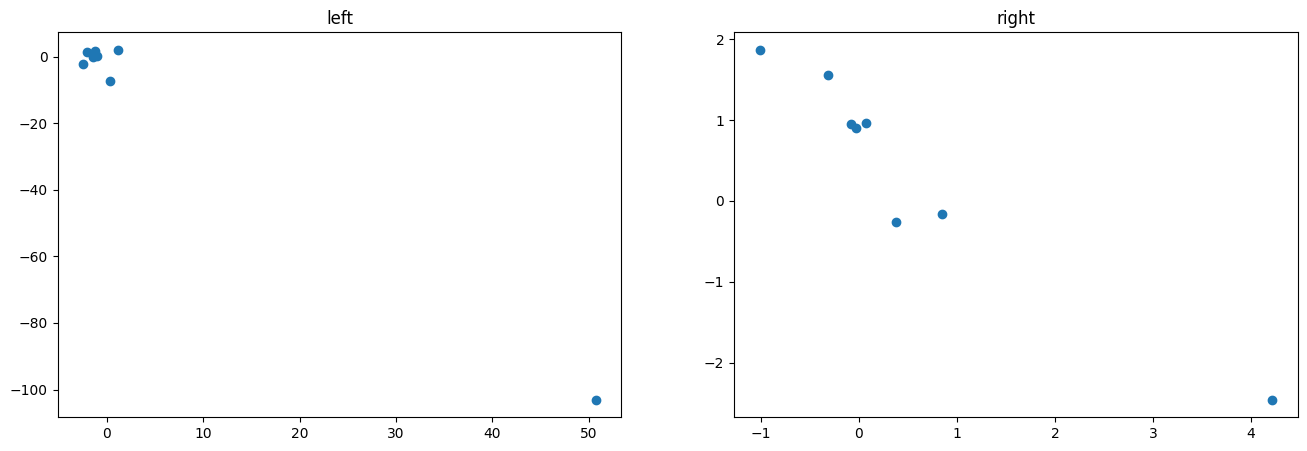

In [4]:
# visualize the synthetic data
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].set_title('left')
ax[0].scatter(*torch.chunk(dehomogenize_points(points_l), 2, dim=-1))
ax[1].set_title('right')
ax[1].scatter(*torch.chunk(dehomogenize_points(points_r), 2, dim=-1))
plt.show()

In [5]:
def get_fundamental_matrix(points_l, points_r):
    """
    Estimate fundamental matrix F using eight-point algorithm based on corresponding pairs

    Parameters
    ----------
    points_l : (N, 3) torch.Tensor
        Array of coordinates of correspondence points from image 1
    points_r : (N, 3), torch.Tensor
        Array of coordinates of correspondence points from image 2

    Returns
    -------
    F : (3, 3) torch.Tensor
    """
    assert points_l.shape[0] == points_r.shape[0]
    assert points_l.shape[0] >= 8, f'Algorithm needs 8+ point to estimate F, but only {points_l.shape[0]} are provided'
    assert points_l.shape[1] == points_r.shape[1] == 3, 'Expected 3d points'

    equations = torch.einsum('bi,bj->bij', points_r, points_l).view(-1, 9)  # Form \tilde{X}
    # For one vector:
    # r = [r1, r2, r3]
    # l = [l1, l2, l3]
    # outer = [[r1*l1, r1*l2, r1*l3],
    #         [r2*l1, r2*l2, r2*l3],
    #         [r3*l1, r3*l2, r3*l3]]

    u, s, v = torch.linalg.svd(equations)
    F = v[-1].view(3, 3)

    return F


def compute_residuals(F, points_l, points_r):
    residuals = torch.einsum('bi,ij,bj->b', points_r, F, points_l)
    return residuals

The function `compute_residuals` calculates

`residuals[j] = points_r[j].T @ F @ points_l[j]` ($\text{residuals}[j] = {x_r^{( j)}}^T F x_l^{( j)}$)

for pairs of points.

As discussed earlier, for a fixed point $x_l$ and fundamental matrix $F$, the equality $x_r^T F x_l = 0$ holds only for points $x_r$ that lie on the corresponding epipolar line $I_r$. Hence, function `compute_residuals` can be used to verify whether point $x_r$ lies on the epipolar line associated with point $x_l$: $x_r^{( j)} \in I_r \Leftrightarrow |\text{residuals}[j]| < \epsilon$

In [6]:
F = get_fundamental_matrix(points_l, points_r)
residuals = compute_residuals(F, points_l, points_r)

print(residuals.abs().max())
assert residuals.abs().max() < 1e-5

tensor(9.8348e-07)


### Real Example

Now, let's move from synthetic data to real example. Suppose we have two images taken from different positions (let's call them the left and right images), and a set of coordinates for corresponding pairs. Our goal is to learn how to match points on the right image to given points on the left one. How can we do that using our methods?

General Pipeline:

1. Estimate the fundamental matrix based on the known coordinates of corresponding pairs.

2. Сonstruct epipolar lines

3. As discussed earlier, the desired points from the right image lie somewhere on the epipolar lines. Therefore, we can iterate over points on these lines and select the ones most 'similar' to the points of interest on the left image. The SIFT algorithm, which we'll discuss later, will help us with this.

In [7]:
!wget https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_02/seminar/right.jpg
!wget https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_02/seminar/left.jpg
!wget https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_02/seminar/correspondences.pt

--2026-01-28 14:37:27--  https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_02/seminar/right.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 291976 (285K) [image/jpeg]
Saving to: ‘right.jpg’

right.jpg           100%[===================>] 285.13K  --.-KB/s    in 0.03s   

2026-01-28 14:37:27 (8.61 MB/s) - ‘right.jpg’ saved [291976/291976]

--2026-01-28 14:37:27--  https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_02/seminar/left.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 293539 (287K) [image

In [8]:
left = plt.imread('left.jpg')
right = plt.imread('right.jpg')
h, w, _ = left.shape  # same shape for left and right
# see https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html for details
correspondences = torch.load('correspondences.pt')  # dict of corresponding pairs
# points are in homogeneous coordinates, however z = 1 for all points
points_l = correspondences['points_l']  # (n, 3) torch.Tensor
points_r = correspondences['points_r']  # (n, 3) torch.Tensor

In [9]:
def plot_correspondences(ax, points_l, points_r, w):
    for point_l, point_r in zip(points_l, points_r):
        ax.plot([point_l[0], point_r[0] + w],
                [point_l[1], point_r[1]],
                marker='o')

In [10]:
def plot_cross_correspondences(ax, points_l, points_r, w):
    ax.scatter(points_l[:, 0], points_l[:, 1],
               s=30, c='blue', marker='x', label='left keypoints')
    ax.scatter(points_r[:, 0] + w, points_r[:, 1],
               s=30, c='green', marker='x', label='right keypoints')

Let's plot the corresponding pairs from our dataset:

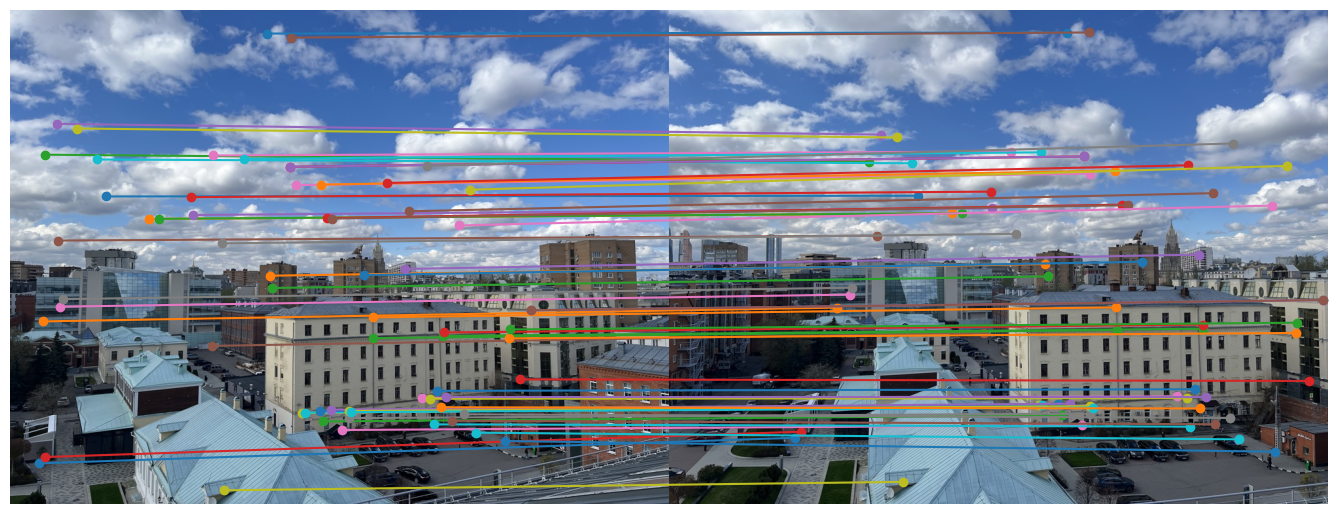

In [11]:
fig, ax = plt.subplots(figsize=(17, 10))
concatenated_image = np.concatenate((left, right), axis=1)
ax.imshow(concatenated_image)
plot_correspondences(ax, points_l, points_r, w)
ax.axis('off')
plt.show()

Estimate the fundamental matrix $F$:

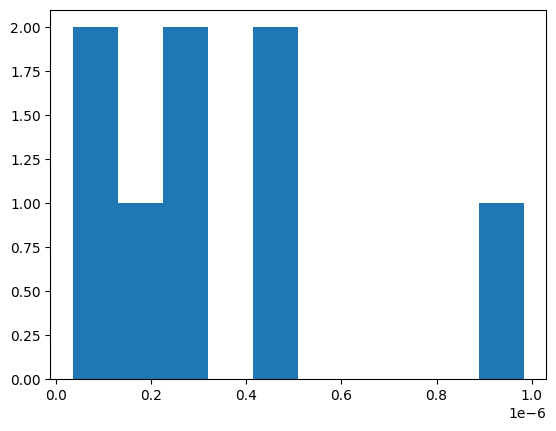

In [12]:
F = get_fundamental_matrix(points_l, points_r)
resiudals = compute_residuals(F, points_l, points_r)
plt.hist(residuals.abs())
plt.show()

In [13]:
def plot_epipolar_lines(ax, F, point_l, point_r, w, c=None):
    # plot two epipolar lines for a single correspondence
    line_l = F.T @ point_r # -> [a, b, c] that defines the straight line ax + by + c = 0 (here (a, b) is normal vector to the straight line)
    line_l_parametric = torch.tensor([line_l[1], -line_l[0]]) # from the normal vector we want to to get codirectional
    line_l_parametric /= line_l_parametric.norm()

    line_r = F @ point_l
    line_r_parametric = torch.tensor([line_r[1], -line_r[0]])
    line_r_parametric /= line_r_parametric.norm()

    point_l = dehomogenize_points(point_l)
    point_r = dehomogenize_points(point_r)

    if c is None:
        c = np.random.rand(1, 3)
    ax.scatter([point_l[0], point_r[0] + w],
               [point_l[1], point_r[1]],
               c=c)
    delta_t = -50
    # left line
    ax.plot([point_l[0] - delta_t * line_l_parametric[0], point_l[0] + delta_t * line_l_parametric[0]],
            [point_l[1] - delta_t * line_l_parametric[1], point_l[1] + delta_t * line_l_parametric[1]],
            c=c)
    # right line
    ax.plot([point_r[0] - delta_t * line_r_parametric[0] + w, point_r[0] + delta_t * line_r_parametric[0] + w],
            [point_r[1] - delta_t * line_r_parametric[1], point_r[1] + delta_t * line_r_parametric[1]],
            c=c)

Epipolar lines for the corresponding points:

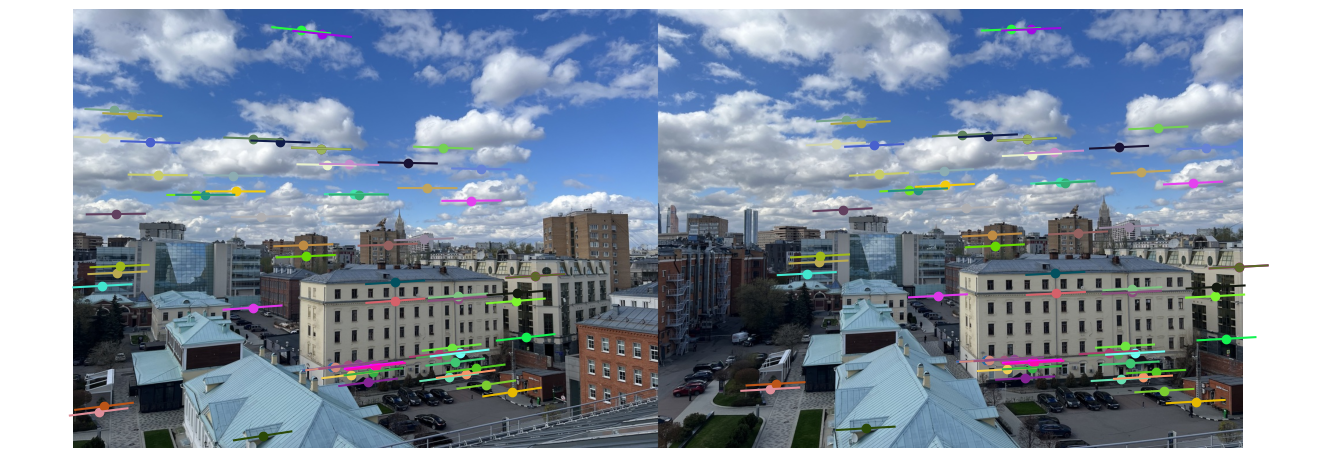

In [14]:
fig, ax = plt.subplots(figsize=(17, 10))
ax.imshow(concatenated_image)
for point_l, point_r in zip(points_l, points_r):
    plot_epipolar_lines(ax, F, point_l, point_r, w)
ax.axis('off')
plt.show()

# plt.savefig('images_with_epipolar_lines.jpg', bbox_inches='tight', dpi=200)

### SIFT

**SIFT** (**S**cale **I**nvariant **F**eature **T**ransform) is an algorithm for detecting and describing local features in images. It represents a local image patch as a numerical vector (feature vector). Crucially, *SIFT is invariant to image scale and rotation*, meaning the same features can be found even if the image is resized or rotated.

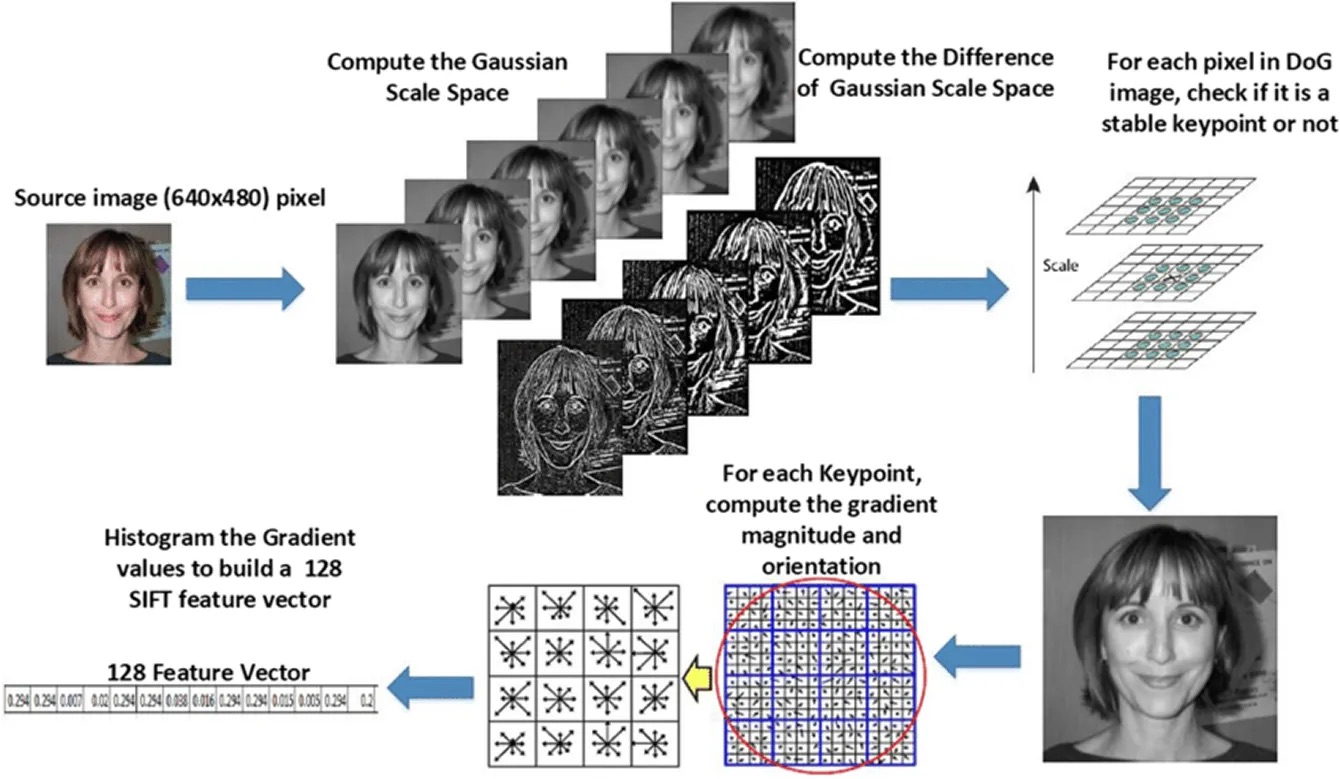

Algorithm:

1. **Scale Space Construction.** The process begins by constructing a Gaussian Scale Space. The source image is progressively blurred using Gaussian convolution with increasing magnitudes. This produces a series of "blurred" images. Next, adjacent blurred images are subtracted from each other to create the Difference of Gaussian (DoG) Scale Space. This step highlights edges and blobs that are stable across different scales.

2. **Keypoint Localization.** To find keypoints, we look for local extrema within the DoG space. We compare each pixel to its neighbors not just in the current image, but also in the images above and below it in the stack (a 3D neighborhood search).
Only points that are strictly larger or smaller than all their neighbors are selected as candidate keypoints. This ensures the points are distinctive with respect to both location and scale.

3. **Orientation and Descriptor Generation.** Once a stable keypoint is localized in the scale space, we calculate its descriptor to enable matching across different images.

    - *Orientation Assignment (Rotation Invariance)*.  
        For every pixel in the neighborhood of the keypoint (using the Gaussian-blurred image at the detected scale), we calculate the gradient magnitude m(x,y) and orientation θ(x,y).  
        L_x = Pixel(x+1,y)−Pixel(x−1,y), L_y=Pixel(x,y+1)−Pixel(x,y−1), m(x,y) = \sqrt{L_x^2 + L_y^2}.  
        φ=(L_y, L_x), θ(x,y) = atan2(φ).  
        These gradient orientations are collected into a histogram weighted by their magnitudes. The highest peak in this histogram identifies the *dominant orientation* of the keypoint.  
        The coordinates of the descriptor are then rotated relative to this dominant orientation, ensuring that the feature description is invariant to image rotation
    - *Descriptor Construction (Grid & Histograms)*.   
        Then we take a 16x16 pixel neighborhood around the keypoint (at this detected scale) and divide it into a *4x4 grid* of subregions.  
        In each subregion, we compute an *8-bin orientation histogram*. The 360 degree range of orientations is divided into 8 bins (each covering 45 degree). Every pixel in the subregion "votes" for a bin based on its direction θ. Crucially, this vote is weighted by the gradient magnitude m and a Gaussian window centered on the keypoint. This ensures that gradients closer to the center of the descriptor contribute more than those at the periphery, reducing the impact of misregistration errors.
    - *Final Feature Vector*.  
        Finally, the histograms from all subregions are concatenated: 4\*4\*8=128.
        This resulting *128-dimensional vector* is normalized to unit length to make the descriptor robust to linear illumination changes (brightness/contrast).

In [15]:
# !pip install --force-reinstall --no-deps opencv-python>=4.4.0

In [16]:
import cv2
import torch
import numpy as np
from matplotlib import pyplot as plt

print(f'cv2 {cv2.__version__}')

cv2 4.12.0


In [17]:
def find_best_matches(F, point_l, sift, left, right, topk=1, neighbourhood=32, n_candidates=500):
    """
        topk - amount of best matches to find
        neighbourhood - neighbourhood of keypoint
        n_candidates - number of points on epipolar line to choose from
    """

    line_r = F @ point_l

    point_l = dehomogenize_points(point_l)
    # descriptor for left keypoint
    (kp_l, desc_l) = sift.compute(left, tuple([cv2.KeyPoint(point_l[0].item(), point_l[1].item(), neighbourhood)]))

    # sample points on right epipolar line to choose matches from
    # point_r = (x_r, y_r, 1)
    # point_r.T @ line_r = point_r.T @ F @ point_l = 0
    # line_r = [a, b, c], epipolar line: ax + by + c = 0 => y = -(ax + c) / b
    x_range = np.linspace(0, right.shape[1], n_candidates)
    right_candidates = [
        cv2.KeyPoint(x, float(- (x * line_r[0] + line_r[2]) / line_r[1]), neighbourhood)
        for x in x_range
    ]

    # descriptors for right candidates
    _, desc_r = sift.compute(right, tuple(right_candidates))

    # choosing the most similar candidates
    distances = np.linalg.norm(desc_l - desc_r, axis=1)
    best_candidates_idxs = list(np.argsort(distances)[:topk])
    best_candidates = np.array(right_candidates)[best_candidates_idxs]
    best_candidates = [candidate.pt for candidate in best_candidates]

    return best_candidates

def plot_best_matches(ax, F, point_l, point_r, sift, left_img, right_img, topk=1, neighbourhood=16, n_candidates=500):
    c = np.random.rand(1, 3)

    ax.scatter([point_l[0], point_r[0] + w], [point_l[1], point_r[1]],
               c=c, zorder=1)
    plot_epipolar_lines(ax, F, point_l, point_r, w, c=c)

    best_candidates = find_best_matches(F, point_l, sift, left_img, right_img,
                                        topk=topk, neighbourhood=neighbourhood, n_candidates=n_candidates)

    ax.scatter([point[0] + w for point in best_candidates],
               [point[1] for point in best_candidates],
               color=c, zorder=2, marker='x')

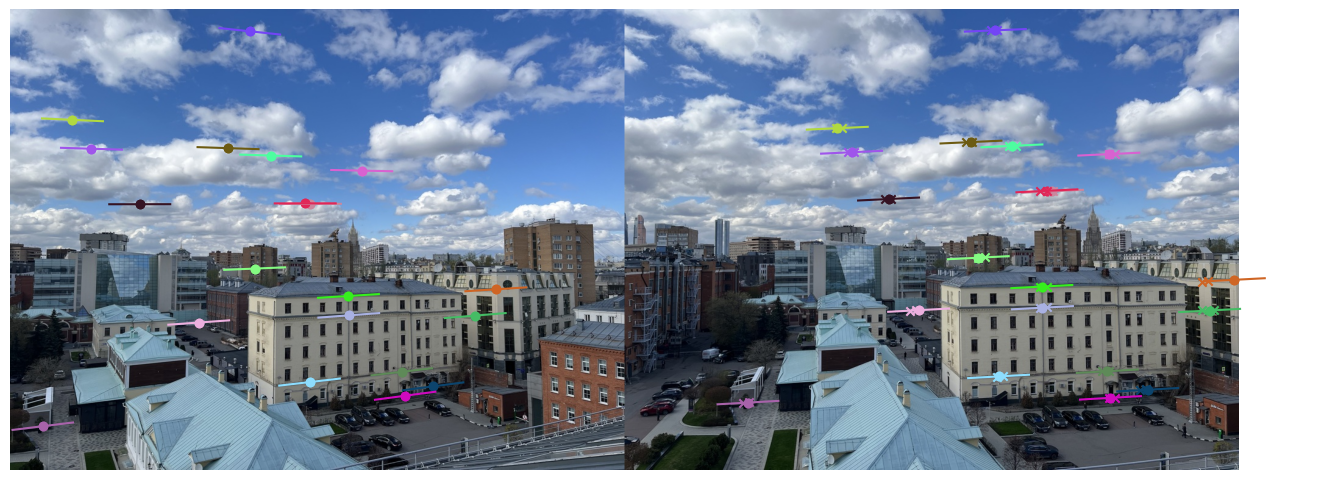

In [18]:
fig, ax = plt.subplots(figsize=(17, 10))
ax.imshow(concatenated_image)

# Initiate SIFT detector
sift = cv2.SIFT_create()  # if cv2 version >= 4.4.0
# sift = cv2.xfeatures2d.SIFT_create() # if cv2 version = 4.3.x

k = 20
show_ids = np.random.permutation(range(len(points_l)))[:k]
for point_l, point_r in zip(points_l[show_ids], points_r[show_ids]):
    plot_best_matches(ax, F, point_l, point_r, sift, left, right, topk=2, n_candidates=100)

ax.axis('off')
plt.show()

### Robust Feature Matching via RANSAC and Epipolar Geometry

Algorithm:
1. **Initial Feature Extraction & Matching**   
First, we detect keypoints and compute their descriptors (e.g., using SIFT) for both images. By comparing descriptors (usually via Nearest Neighbor search), we generate a set of expected matches.  
*Problem:* This initial set typically contains many false matches (outliers) because appearance alone is not enough to guarantee correct correspondence.

2. **Outlier Rejection using RANSAC** (**Ran**dom **Sa**mple **C**onsensus)  
To filter out these errors, we apply the RANSAC algorithm combined with the Fundamental Matrix (F) estimation. The core idea is that correct matches must satisfy the rigid geometric constraints of the scene (epipolar geometry).

    The RANSAC loop proceeds as follows:
    - *Hypothesize.* Randomly sample a minimal subset of point pairs (typically 8 pairs) to compute a candidate Fundamental Matrix F using the Eight-Point Algorithm.
    - *Verify (Count Inliers).* Test all other expected matches against this candidate F. A match (x_1, x_2) is considered an inlier if it satisfies the epipolar constraint: (x_2)^T F x_1 = 0. Geometrically, this checks if point x_2 lies close to the epipolar line generated by x_1.
    - *Select Best Model.* Repeat the loop for a fixed number of iterations. The matrix F that explains the largest number of matches (highest inlier count) is selected as the best model.

3. **Final Refinement**  
The matches that agree with the best Fundamental Matrix are kept as valid correspondences (inliers), while the rest are discarded as outliers. Optionally, the Fundamental Matrix can be re-estimated using all inliers to improve precision.


Detect key points for both images and compute descriptors for them:

In [19]:
sift = cv2.SIFT_create()

kp_left, des_left = sift.detectAndCompute(left, None)
kp_right, des_right = sift.detectAndCompute(right, None)

print(f'Number of found key points:'
      f'\n{len(kp_left)} for left  image'
      f'\n{len(kp_right)} for right image')

Number of found key points:
3531 for left  image
3651 for right image


In [20]:
# Extract matching points
pts_l = torch.tensor([point.pt for point in kp_left])
pts_r = torch.tensor([point.pt for point in kp_right])

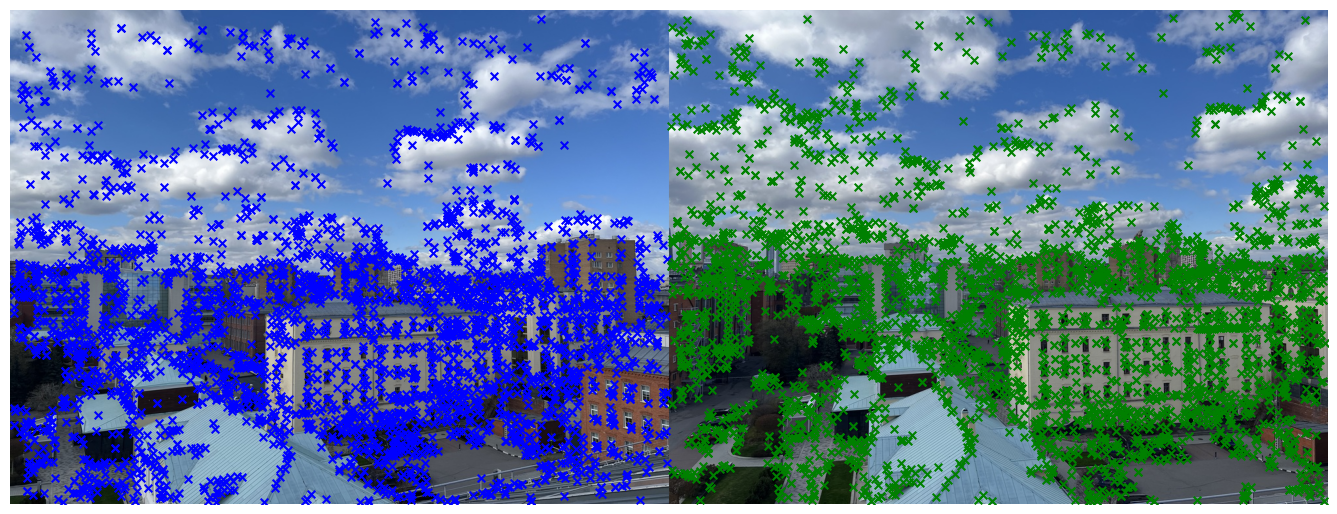

In [21]:
fig, ax = plt.subplots(figsize=(17, 10))
concatenated_image = np.concatenate((left, right), axis=1)
ax.imshow(concatenated_image)
plot_cross_correspondences(ax, pts_l, pts_r, w)
plt.axis('off')
plt.show()

Now let’s match these points between the images:

In [22]:
def match_descriptors_manual(des1, des2, ratio_thresh=0.75):
    """
        Matches descriptors using 2 nearest neighbours search and Lowe's ratio test.
    """
    matches = []
    for idx1, d1 in enumerate(des1):
        distances = np.linalg.norm(des2 - d1, axis=1)

        nn_idx = np.argsort(distances)[:2]
        d1_idx, d2_idx = nn_idx[0].item(), nn_idx[1].item()

        # Apply Lowe's ratio test: if descriptors are very similar d1/d2 ≈ 1 => we don't need them
        # Helps to throw out bad matches: for example, if there are many similar patterns, it's not clear which one to take
        if distances[d1_idx] < ratio_thresh * distances[d2_idx]:
            matches.append((idx1, d1_idx))

    return matches


def get_matched_keypoints(kp_left, kp_right, matches):
    """
        Turns a list of mappings into arrays of point coordinates.
    """
    pts_left = torch.tensor([kp_left[i].pt for (i, _) in matches])
    pts_right = torch.tensor([kp_right[j].pt for (_, j) in matches])
    return pts_left, pts_right

In [23]:
idx_matches = match_descriptors_manual(des_left, des_right, ratio_thresh=0.75)
matched_left, matched_right = get_matched_keypoints(kp_left, kp_right, idx_matches)

print('Matched points:', len(idx_matches))

Matched points: 731


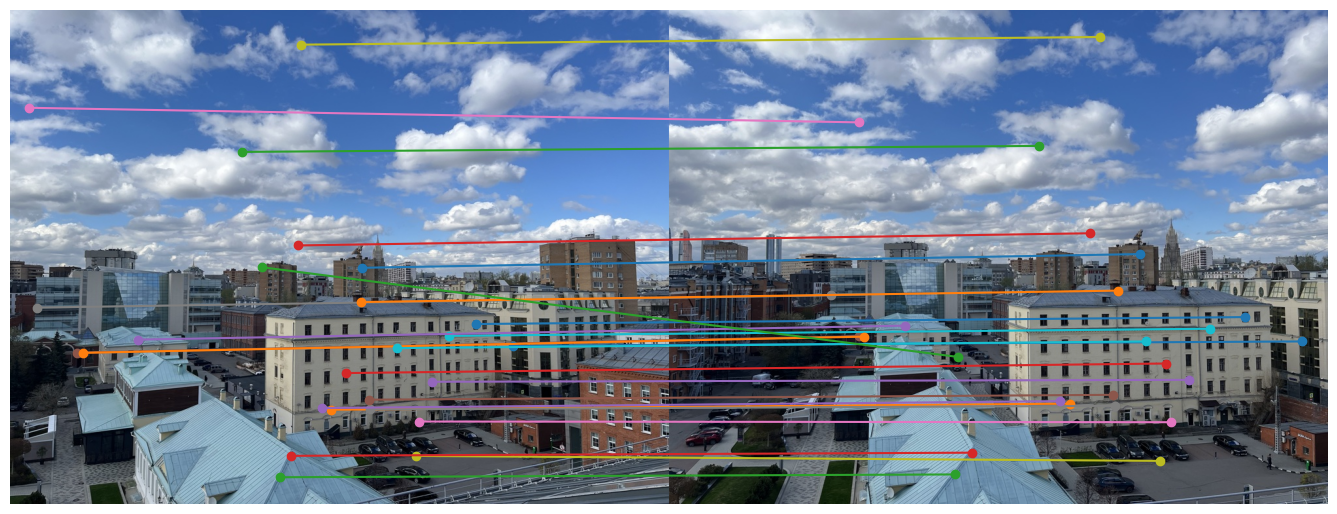

In [24]:
def plot_matches(ax, points_l, points_r, w):
    for point_l, point_r in zip(points_l, points_r):
        ax.plot([point_l[0], point_r[0] + w],
                [point_l[1], point_r[1]],
               marker='o')

fig, ax = plt.subplots(figsize=(17, 10))
concatenated_image = np.concatenate((left, right), axis=1)
ax.imshow(concatenated_image)

k = 25
show_ids = np.random.permutation(range(len(idx_matches)))[:k]
plot_matches(ax, matched_left[show_ids], matched_right[show_ids], w)

plt.axis('off')
plt.show()

Obtain our fundamental matrix F using the RANSAC algorithm.

In [42]:
# RANSAC parameters
NUM_ITERATIONS = 2000
THRESHOLD = 0.01
MIN_INLIERS = 8

best_F = None
best_inliers_count = 0
best_mask = None

pts1 = homogenize_points(matched_left)  # [N, 3]
pts2 = homogenize_points(matched_right) # [N, 3]
num_points = len(pts1)

for _ in tqdm(range(NUM_ITERATIONS)):
    # sample subset of 8 point pairs
    indices = torch.randperm(num_points)[:8]
    sample1 = pts1[indices]
    sample2 = pts2[indices]

    # compute fundamental matrix F
    try:
        F_candidate = get_fundamental_matrix(sample1, sample2)
    except:
        # if 8 points are degenerate (lie on the same line), continue
        continue

    # find inliers
    res = compute_residuals(F_candidate, pts1, pts2)
    current_inliers = (res.abs() < THRESHOLD)
    count = current_inliers.sum().item()

    # choose best model
    if count > best_inliers_count:
        best_inliers_count = count
        best_F = F_candidate
        best_mask = current_inliers

# final recalculating
if best_inliers_count >= MIN_INLIERS:
    # take only inliers
    final_pts1 = pts1[best_mask]
    final_pts2 = pts2[best_mask]
    F_final = get_fundamental_matrix(final_pts1, final_pts2)
else:
    raise ValueError("RANSAC failed: too few inliers found")

print(f"\n\nFound {best_inliers_count} inliers out of {num_points} matches")
residuals = compute_residuals(F_final, pts1, pts2)
print("\nFinal max residual:", residuals.abs().max().item())
print("Final mean residual:", residuals.abs().mean().item())

100%|██████████| 2000/2000 [00:01<00:00, 1662.64it/s]



Found 506 inliers out of 731 matches

Final max residual: 0.984003484249115
Final mean residual: 0.02622714452445507
